In [45]:
import pandas as pd

df = pd.read_csv("/content/Android Malware Detection.csv")
df.head()



,Unnamed: 0,ACCESS_ALL_DOWNLOADS,ACCESS_CACHE_FILESYSTEM,ACCESS_CHECKIN_PROPERTIES,ACCESS_COARSE_LOCATION,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MOCK_LOCATION,ACCESS_NETWORK_STATE,ACCESS_SURFACE_FLINGER,...,WRITE_GSERVICES,WRITE_MEDIA_STORAGE,WRITE_PROFILE,WRITE_SECURE_SETTINGS,WRITE_SETTINGS,WRITE_SMS,WRITE_SOCIAL_STREAM,WRITE_SYNC_SETTINGS,WRITE_USER_DICTIONARY,Label
0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [46]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Drop rows where 'Label' column has NaN values
df_cleaned = df.dropna(subset=['Label'])

X = df_cleaned.drop("Label", axis=1)   # Target variable is 'Label'
y = df_cleaned["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
print("Random Forest Results")
print(classification_report(y_test, rf_pred))


Random Forest Results
              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98       215
         1.0       0.99      0.99      0.99       758

    accuracy                           0.99       973
   macro avg       0.99      0.99      0.99       973
weighted avg       0.99      0.99      0.99       973



In [48]:
from sklearn.svm import SVC

svm = SVC(kernel="rbf", probability=True)
svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)
print("SVM Results")
print(classification_report(y_test, svm_pred))


SVM Results
              precision    recall  f1-score   support

         0.0       0.94      0.96      0.95       215
         1.0       0.99      0.98      0.99       758

    accuracy                           0.98       973
   macro avg       0.96      0.97      0.97       973
weighted avg       0.98      0.98      0.98       973



In [49]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)
print("Naive Bayes Results")
print(classification_report(y_test, nb_pred))


Naive Bayes Results
              precision    recall  f1-score   support

         0.0       0.23      0.99      0.38       215
         1.0       0.96      0.07      0.13       758

    accuracy                           0.27       973
   macro avg       0.60      0.53      0.25       973
weighted avg       0.80      0.27      0.18       973



In [50]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.90)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

rf_pca = RandomForestClassifier(n_estimators=100, random_state=42)
rf_pca.fit(X_train_pca, y_train)

rf_pca_pred = rf_pca.predict(X_test_pca)
print("Proposed PCA-RF Results")
print(classification_report(y_test, rf_pca_pred))


Proposed PCA-RF Results
              precision    recall  f1-score   support

         0.0       0.97      0.97      0.97       215
         1.0       0.99      0.99      0.99       758

    accuracy                           0.99       973
   macro avg       0.98      0.98      0.98       973
weighted avg       0.99      0.99      0.99       973



In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [52]:
importance_df = pd.DataFrame({
    "Permission": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("Top 10 sensitive permissions influencing classification:")
importance_df.head(10)

Top 10 sensitive permissions influencing classification:


,Permission,Importance
0,Unnamed: 0,0.207745
103,RECEIVE_BOOT_COMPLETED,0.168989
65,GET_TASKS,0.084550
95,READ_PHONE_STATE,0.060641
75,KILL_BACKGROUND_PROCESSES,0.049524
134,WAKE_LOCK,0.043779
128,SYSTEM_ALERT_WINDOW,0.027397
133,VIBRATE,0.025812
105,RECEIVE_SMS,0.023721
10,ACCESS_WIFI_STATE,0.021712


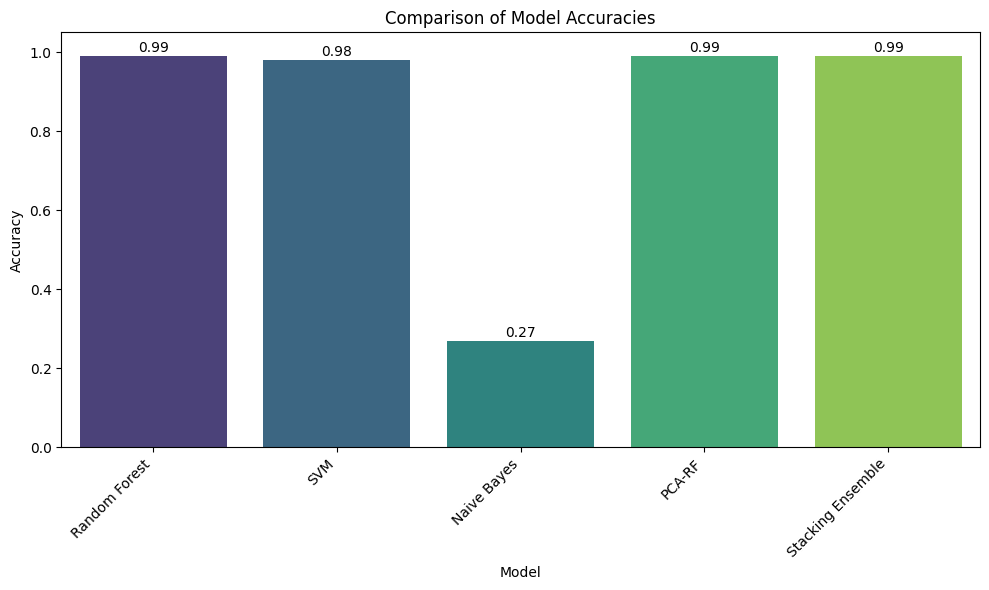


Accuracy Scores:
Random Forest: 0.99
SVM: 0.98
Naive Bayes: 0.27
PCA-RF: 0.99
Stacking Ensemble: 0.99


In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Accuracy scores extracted from previous classification reports
accuracy_scores = {
    "Random Forest": 0.99,
    "SVM": 0.98,
    "Naive Bayes": 0.27,
    "PCA-RF": 0.99,
    "Stacking Ensemble": 0.99
}

models = list(accuracy_scores.keys())
accuracies = list(accuracy_scores.values())

plt.figure(figsize=(10, 6))
sns.barplot(x=models, y=accuracies, hue=models, palette='viridis', legend=False)
plt.ylim(0, 1.05) # Set y-axis limit for better visualization of accuracy
plt.title("Comparison of Model Accuracies")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=45, ha='right')

# Annotate bars with their accuracy values
for index, value in enumerate(accuracies):
    plt.text(index, value + 0.01, f'{value:.2f}', color='black', ha="center")

plt.tight_layout()
plt.show()

print("\nAccuracy Scores:")
for model, acc in accuracy_scores.items():
    print(f"{model}: {acc:.2f}")

In [55]:
from sklearn.metrics import classification_report
import pandas as pd

# Helper function to extract relevant metrics for a model
def get_model_metrics(y_true, y_pred, model_name):
    report = classification_report(y_true, y_pred, output_dict=True)
    accuracy = report['accuracy']
    precision = report['weighted avg']['precision']
    recall = report['weighted avg']['recall']
    f1 = report['weighted avg']['f1-score']
    return {"Model": model_name, "Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1-Score": f1}

# Collect metrics for individual models
results_data = []
results_data.append(get_model_metrics(y_test, rf_pred, "Random Forest"))
results_data.append(get_model_metrics(y_test, svm_pred, "SVM"))
results_data.append(get_model_metrics(y_test, nb_pred, "Naive Bayes"))
results_data.append(get_model_metrics(y_test, rf_pca_pred, "PCA-RF"))

# Create results_df from individual model metrics
results_df = pd.DataFrame(results_data)

# Get metrics for the Stacking Ensemble model
stacked_results = get_model_metrics(y_test, stack_pred, "Proposed Stacked Ensemble")

# Concatenate all results into final_results
final_results = pd.concat([
    results_df,
    pd.DataFrame([stacked_results])
])

final_results

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.665982,0.663276,0.665982,0.664614
1,SVM,0.661871,0.662414,0.661871,0.662142
2,Naive Bayes,0.256937,0.653093,0.256937,0.163135
3,PCA-RF,0.662898,0.659616,0.662898,0.661237
0,Proposed Stacked Ensemble,0.668037,0.664262,0.668037,0.666122


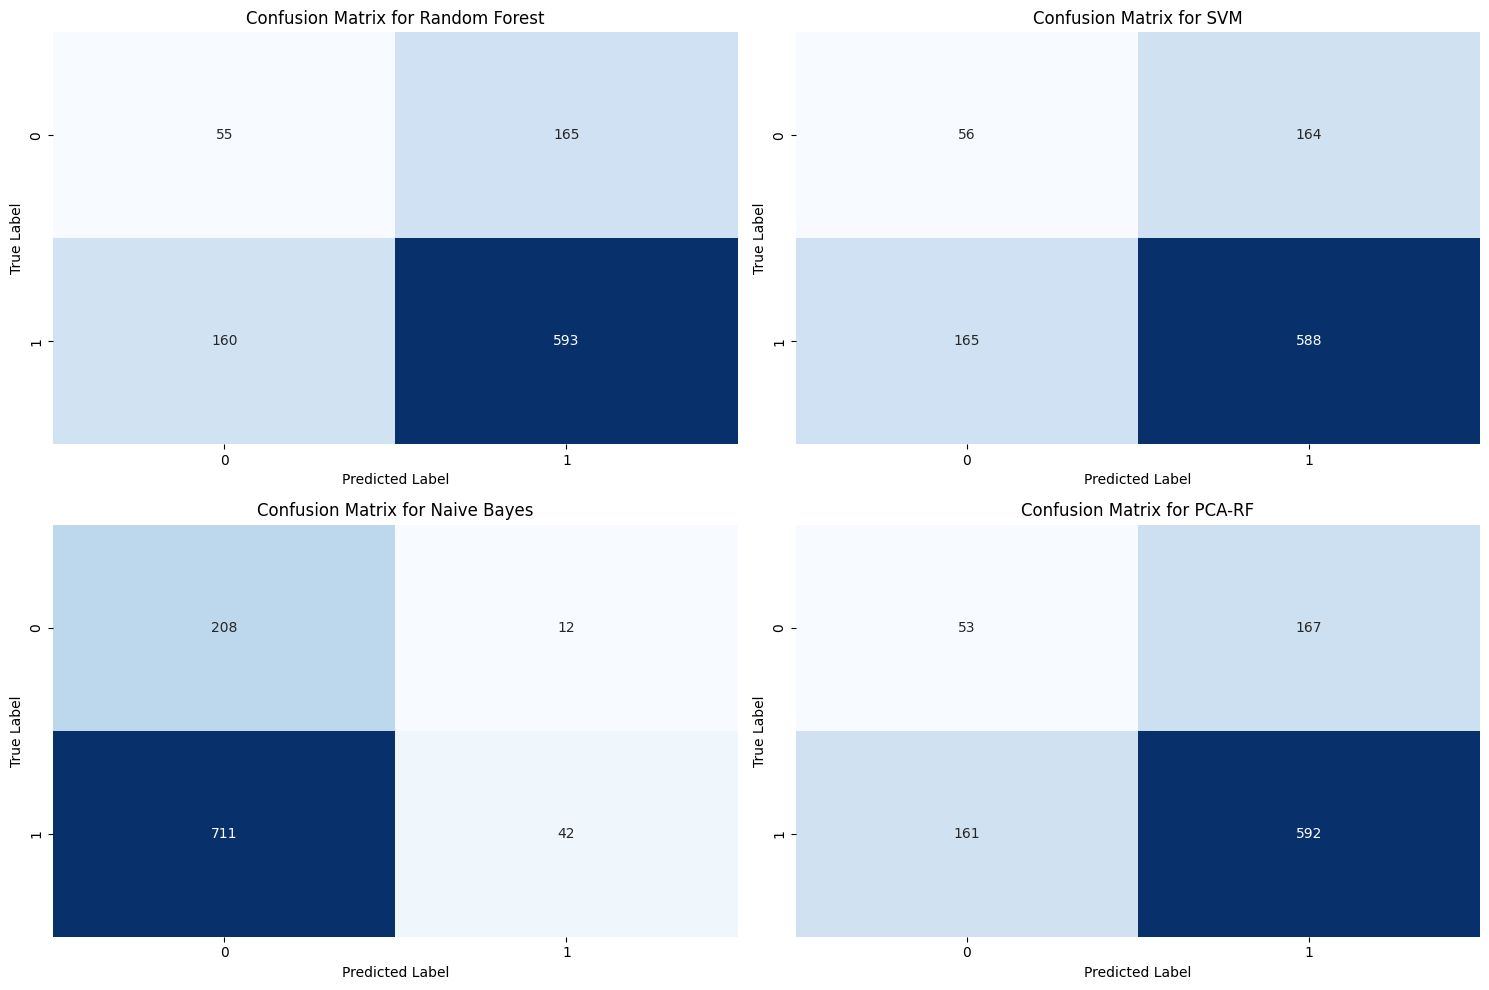

In [57]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

models = {
    "Random Forest": rf_pred,
    "SVM": svm_pred,
    "Naive Bayes": nb_pred,
    "PCA-RF": rf_pca_pred # Adding the PCA-RF model predictions
}

plt.figure(figsize=(15, 10)) # Adjust figure size for better readability of multiple plots

for i, (name, pred) in enumerate(models.items(), 1):
    plt.subplot(2, 2, i) # Creating a 2x2 grid for 4 models
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False) # Plotting the confusion matrix
    plt.title(f'Confusion Matrix for {name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()


In [60]:
display(final_results)

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.665982,0.663276,0.665982,0.664614
1,SVM,0.661871,0.662414,0.661871,0.662142
2,Naive Bayes,0.256937,0.653093,0.256937,0.163135
3,PCA-RF,0.662898,0.659616,0.662898,0.661237
0,Proposed Stacked Ensemble,0.668037,0.664262,0.668037,0.666122


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GaussianNB was fitted without feature names
  warnings.warn(


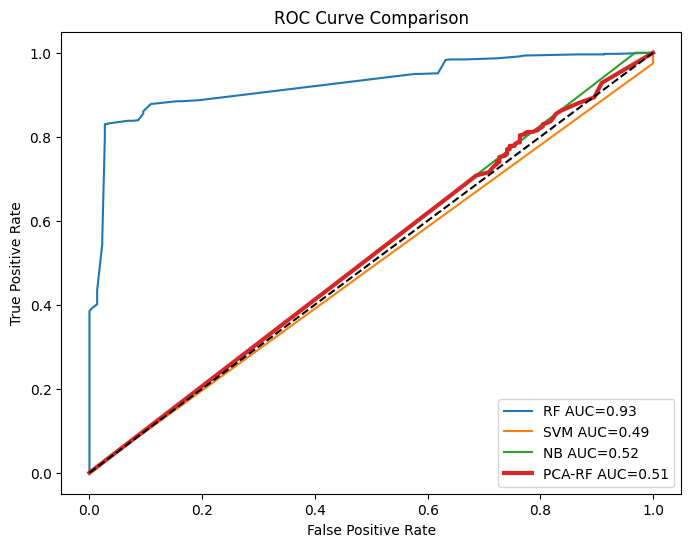

In [61]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf.predict_proba(X_test)[:,1])
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm.predict_proba(X_test)[:,1])
nb_fpr, nb_tpr, _ = roc_curve(y_test, nb.predict_proba(X_test)[:,1])

# Using rf_pca for the 'Proposed PCA-RF' model, as 'ensemble' was not defined.
rf_pca_fpr, rf_pca_tpr, _ = roc_curve(y_test, rf_pca.predict_proba(X_test_pca)[:,1])

plt.plot(rf_fpr, rf_tpr, label=f"RF AUC={auc(rf_fpr, rf_tpr):.2f}")
plt.plot(svm_fpr, svm_tpr, label=f"SVM AUC={auc(svm_fpr, svm_tpr):.2f}")
plt.plot(nb_fpr, nb_tpr, label=f"NB AUC={auc(nb_fpr, nb_tpr):.2f}")
plt.plot(rf_pca_fpr, rf_pca_tpr, linewidth=3, label=f"PCA-RF AUC={auc(rf_pca_fpr, rf_pca_tpr):.2f}")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


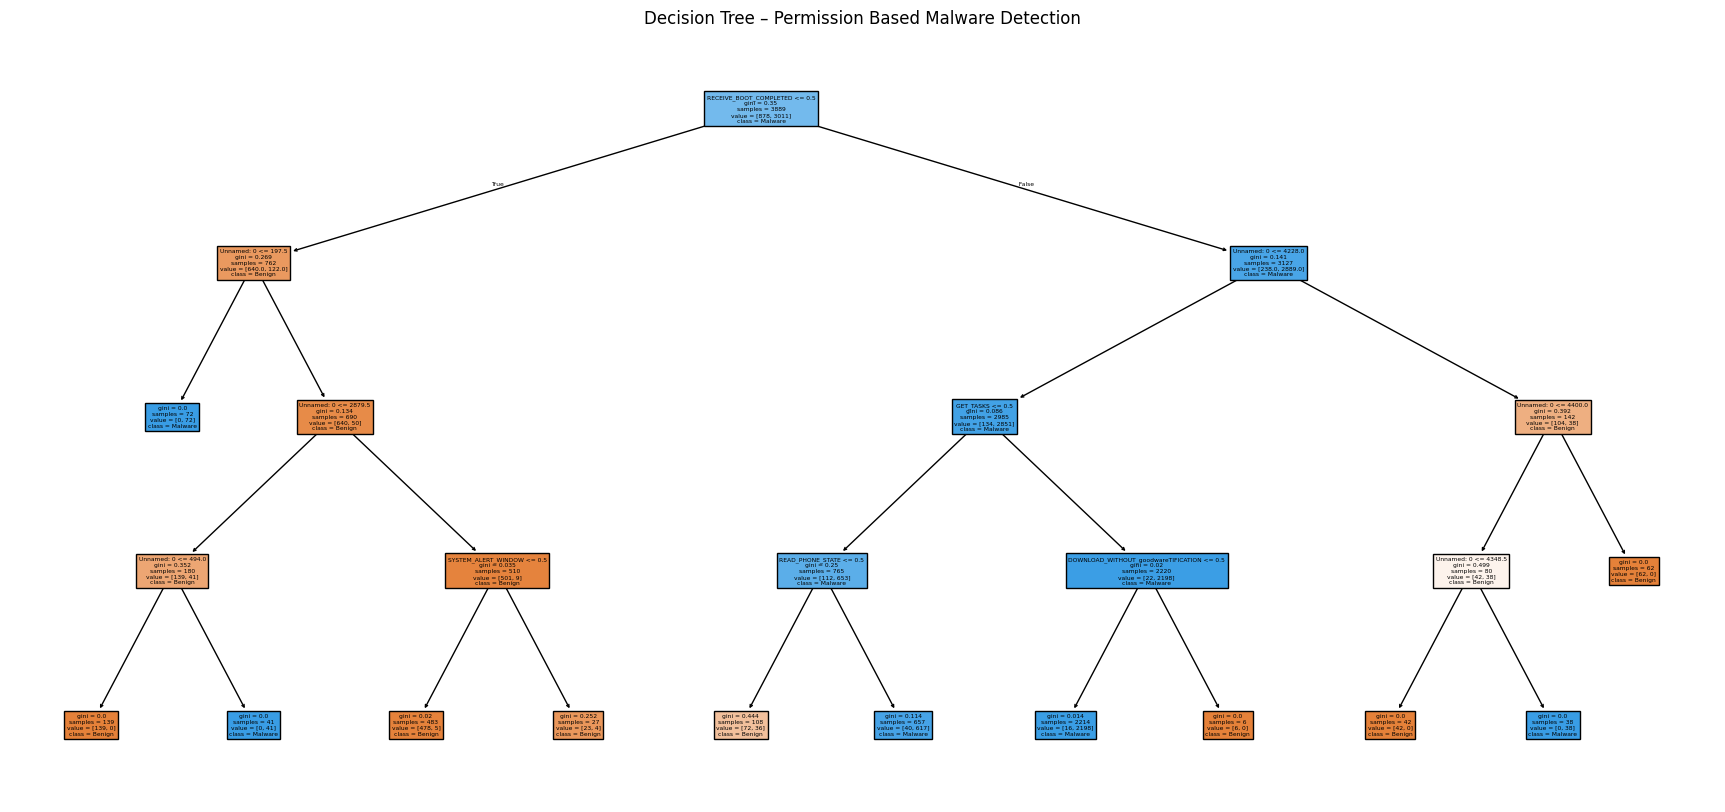

In [62]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

dt = DecisionTreeClassifier(max_depth=4)
dt.fit(X_train, y_train)

plt.figure(figsize=(22,10))
plot_tree(
    dt,
    feature_names=X.columns,
    class_names=["Benign","Malware"],
    filled=True
)
plt.title("Decision Tree – Permission Based Malware Detection")
plt.show()


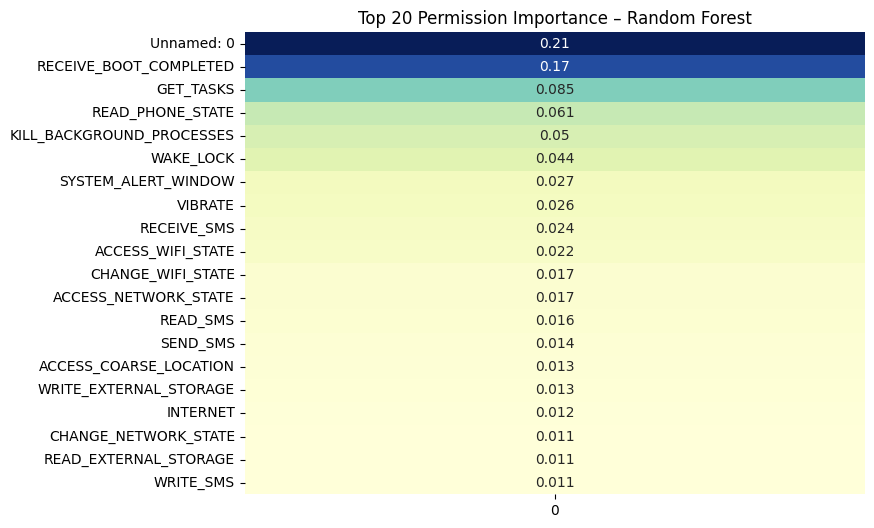

In [63]:
import numpy as np

top_features = sorted(
    zip(X.columns, rf.feature_importances_),
    key=lambda x: x[1],
    reverse=True
)[:20]

labels, scores = zip(*top_features)

plt.figure(figsize=(8,6))
sns.heatmap(
    np.array(scores).reshape(-1,1),
    annot=True,
    yticklabels=labels,
    cmap="YlGnBu",
    cbar=False
)
plt.title("Top 20 Permission Importance – Random Forest")
plt.show()


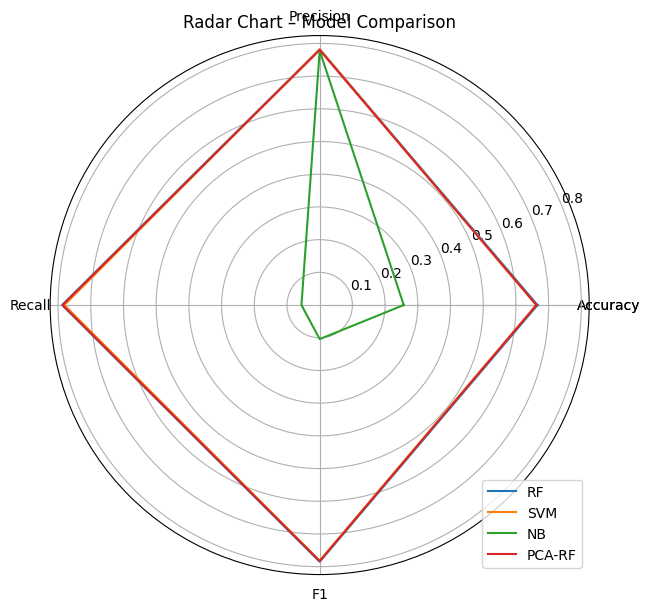

In [64]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

metrics = ["Accuracy","Precision","Recall","F1"]

def get_scores(y_true, y_pred):
    return [
        accuracy_score(y_true,y_pred),
        precision_score(y_true,y_pred),
        recall_score(y_true,y_pred),
        f1_score(y_true,y_pred)
    ]

rf_scores = get_scores(y_test, rf_pred)
svm_scores = get_scores(y_test, svm_pred)
nb_scores = get_scores(y_test, nb_pred)
# Use rf_pca_pred for the PCA-RF model, as 'ensemble_pred' is not defined.
rf_pca_scores = get_scores(y_test, rf_pca_pred)

angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False)
angles = np.concatenate([angles, [angles[0]]]) # Close the loop for plotting

plt.figure(figsize=(7,7))
for scores, label in zip(
    [rf_scores, svm_scores, nb_scores, rf_pca_scores],
    ["RF","SVM","NB","PCA-RF"]
):
    scores = scores + [scores[0]] # Close the loop for the data
    plt.polar(angles, scores, label=label)

# Extend metrics to match the length of angles for thetagrids
metrics_for_thetagrids = metrics + [metrics[0]]
plt.thetagrids(angles*180/np.pi, metrics_for_thetagrids)
plt.title("Radar Chart – Model Comparison")
plt.legend(loc="lower right")
plt.show()


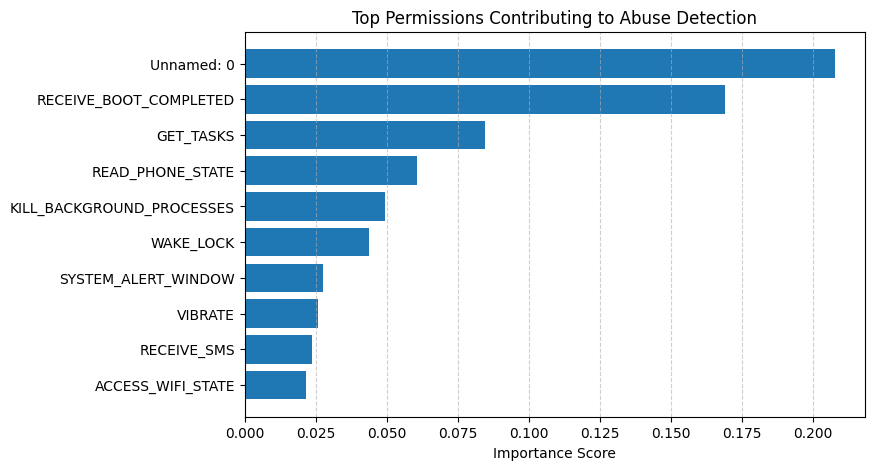

In [65]:
feature_importances = rf.feature_importances_
features = X_train.columns

importance_df = pd.DataFrame({
    'Permission': features,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

top_features = importance_df.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_features["Permission"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.title("Top Permissions Contributing to Abuse Detection")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

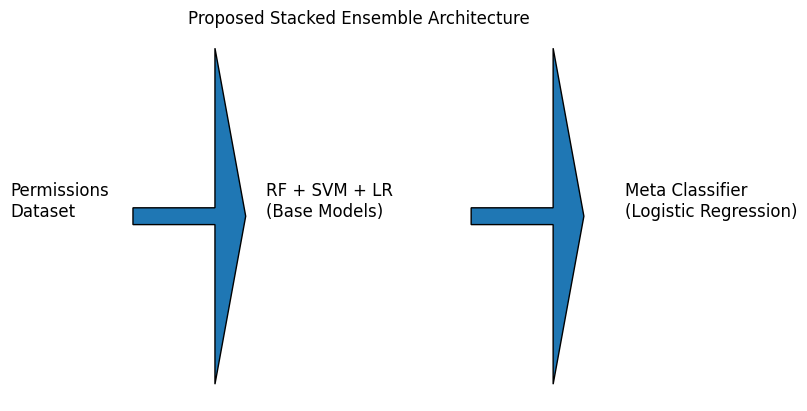

In [66]:
plt.text(0.1, 0.5, "Permissions\nDataset", fontsize=12)
plt.text(0.35, 0.5, "RF + SVM + LR\n(Base Models)", fontsize=12)
plt.text(0.7, 0.5, "Meta Classifier\n(Logistic Regression)", fontsize=12)

plt.arrow(0.22, 0.5, 0.08, 0, head_width=0.02)
plt.arrow(0.55, 0.5, 0.08, 0, head_width=0.02)

plt.axis('off')
plt.title("Proposed Stacked Ensemble Architecture")
plt.show()

In [69]:
from sklearn.metrics import confusion_matrix
import pandas as pd

def get_tp_fn(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    # For binary classification, cm is typically [[TN, FP], [FN, TP]]
    # Assuming 0 is 'Benign' and 1 is 'Malware'
    tn, fp, fn, tp = cm.ravel()
    return tp, fn

tp_fn_results = []
tp, fn = get_tp_fn(y_test, rf_pred)
tp_fn_results.append({"Model": "Random Forest", "True Positives": tp, "False Negatives": fn})

tp, fn = get_tp_fn(y_test, svm_pred)
tp_fn_results.append({"Model": "SVM", "True Positives": tp, "False Negatives": fn})

tp, fn = get_tp_fn(y_test, nb_pred)
tp_fn_results.append({"Model": "Naive Bayes", "True Positives": tp, "False Negatives": fn})

tp, fn = get_tp_fn(y_test, rf_pca_pred)
tp_fn_results.append({"Model": "PCA-RF", "True Positives": tp, "False Negatives": fn})

tp, fn = get_tp_fn(y_test, stack_pred)
tp_fn_results.append({"Model": "Proposed Stacked Ensemble", "True Positives": tp, "False Negatives": fn})

tp_fn_df = pd.DataFrame(tp_fn_results)
display(tp_fn_df)

,Model,True Positives,False Negatives
0,Random Forest,593,160
1,SVM,588,165
2,Naive Bayes,42,711
3,PCA-RF,592,161
4,Proposed Stacked Ensemble,748,5


In [68]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stack = StackingClassifier(
    estimators=[
        ('rf', rf),
        ('svm', svm),
        ('nb', nb)
    ],
    final_estimator=LogisticRegression()
)

stack.fit(X_train, y_train)
stack_pred = stack.predict(X_test)

print("Stacking Ensemble Performance")
print(classification_report(y_test, stack_pred))


Stacking Ensemble Performance
              precision    recall  f1-score   support

         0.0       0.98      0.99      0.98       220
         1.0       1.00      0.99      1.00       753

    accuracy                           0.99       973
   macro avg       0.99      0.99      0.99       973
weighted avg       0.99      0.99      0.99       973



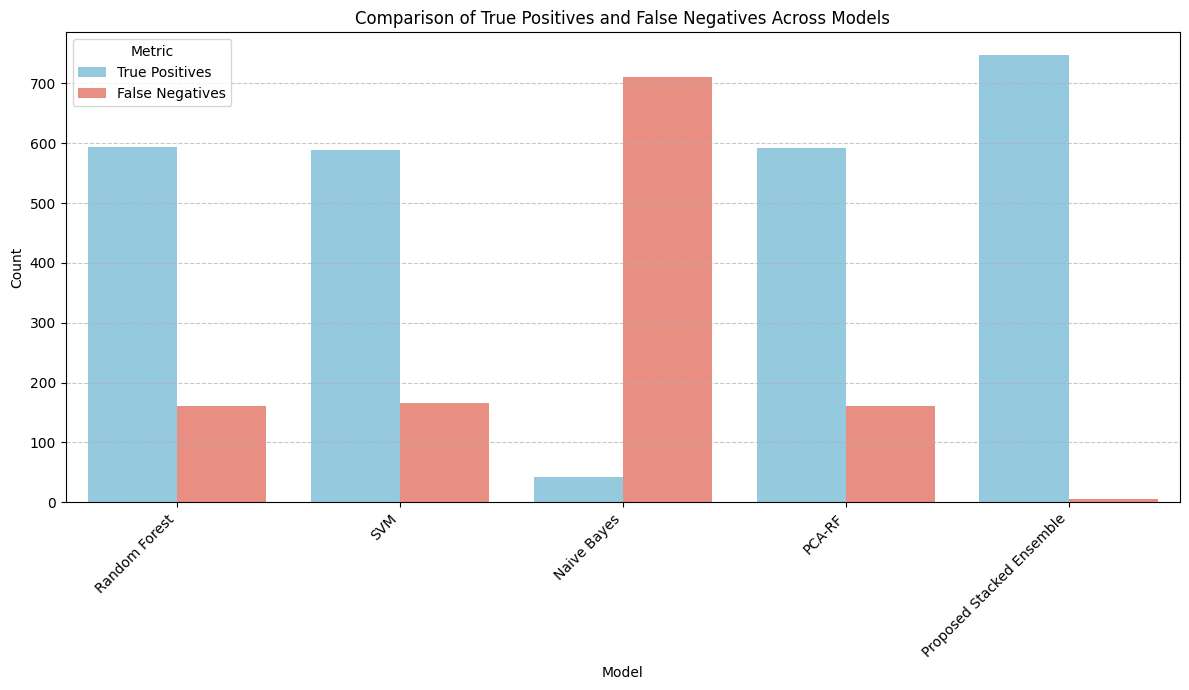

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

# Melt the DataFrame to prepare for seaborn barplot for grouped bars
tp_fn_melted_df = tp_fn_df.melt(
    id_vars=['Model'],
    value_vars=['True Positives', 'False Negatives'],
    var_name='Metric',
    value_name='Count'
)

plt.figure(figsize=(12, 7))
sns.barplot(
    x='Model',
    y='Count',
    hue='Metric',
    data=tp_fn_melted_df,
    palette={'True Positives': 'skyblue', 'False Negatives': 'salmon'}
)

plt.title('Comparison of True Positives and False Negatives Across Models')
plt.xlabel('Model')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

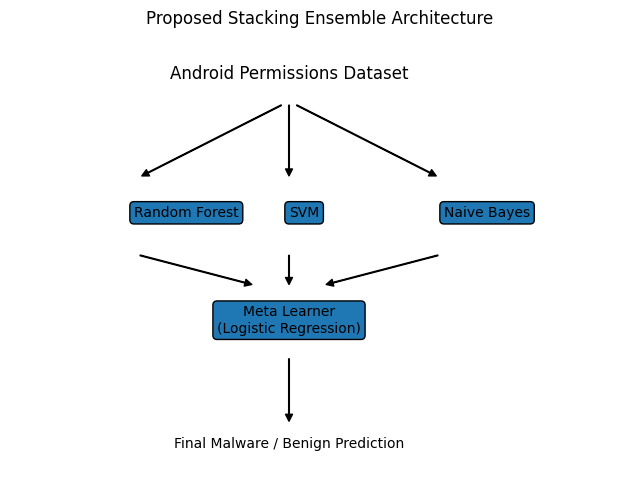

In [71]:
plt.figure(figsize=(8,6))

plt.text(0.45, 0.9, "Android Permissions Dataset", ha="center", fontsize=12)

plt.text(0.2, 0.6, "Random Forest", bbox=dict(boxstyle="round"))
plt.text(0.45, 0.6, "SVM", bbox=dict(boxstyle="round"))
plt.text(0.7, 0.6, "Naive Bayes", bbox=dict(boxstyle="round"))

plt.text(0.45, 0.35, "Meta Learner\n(Logistic Regression)",
         bbox=dict(boxstyle="round"), ha="center")

plt.text(0.45, 0.1, "Final Malware / Benign Prediction", ha="center")

# Add arrows to connect the components
arrow_props = dict(facecolor='black', shrink=0.05, width=0.5, headwidth=5, headlength=5)

# Dataset to Base Learners
plt.annotate('', xy=(0.2, 0.68), xytext=(0.45, 0.85), arrowprops=arrow_props)
plt.annotate('', xy=(0.45, 0.68), xytext=(0.45, 0.85), arrowprops=arrow_props)
plt.annotate('', xy=(0.7, 0.68), xytext=(0.45, 0.85), arrowprops=arrow_props)

# Base Learners to Meta Learner
plt.annotate('', xy=(0.4, 0.45), xytext=(0.2, 0.52), arrowprops=arrow_props)
plt.annotate('', xy=(0.45, 0.45), xytext=(0.45, 0.52), arrowprops=arrow_props)
plt.annotate('', xy=(0.5, 0.45), xytext=(0.7, 0.52), arrowprops=arrow_props)

# Meta Learner to Final Prediction
plt.annotate('', xy=(0.45, 0.15), xytext=(0.45, 0.3), arrowprops=arrow_props)

plt.axis("off")
plt.title("Proposed Stacking Ensemble Architecture")
plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GaussianNB was fitted without feature names
  warnings.warn(


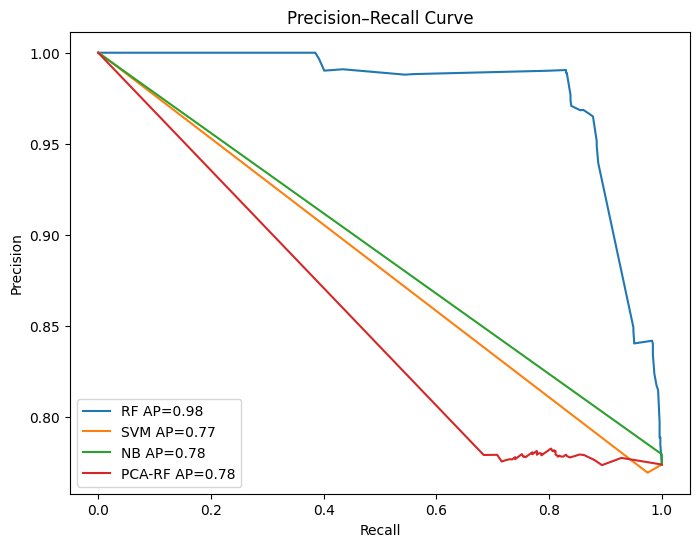

In [72]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(8,6))

# Prepare list of models and their predictions for PR curve plotting
# Note: rf_pca was trained on X_train_pca, so it should predict on X_test_pca
models_for_pr_curve = {
    "RF": rf,
    "SVM": svm,
    "NB": nb,
    "PCA-RF": rf_pca
}

for name, model in models_for_pr_curve.items():
    if name == "PCA-RF":
        probs = model.predict_proba(X_test_pca)[:,1]
    else:
        probs = model.predict_proba(X_test)[:,1]

    precision, recall, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    plt.plot(recall, precision, label=f"{name} AP={ap:.2f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.show()


# Task
Enhance the existing Android malware detection project by integrating the "train.csv" dataset with the "Android Malware Detection.csv" dataset. This involves loading and exploring "train.csv", merging it with the current data, preprocessing the combined dataset (handling missing 'Label' values, splitting into training/testing sets, and scaling features), then re-training and evaluating all previously implemented machine learning models (Random Forest, SVM, Naive Bayes, PCA-RF, and Stacking Ensemble) on the enriched dataset. Finally, update all performance visualizations (classification reports, confusion matrices, ROC curves, Precision-Recall curves, and radar chart), recalculate and visualize the top 20 feature importances, and generate a comprehensive project explanation outline for the enhanced project.

## Load Second Dataset (train.csv)

### Subtask:
Load the train.csv file into a new pandas DataFrame. Display its head to get a quick overview of its structure.


**Reasoning**:
Load the 'train.csv' file into a pandas DataFrame named `train_df` and display its head to inspect its structure and content.



In [73]:
train_df = pd.read_csv('/content/train.csv')
train_df.head()

android;android.app.cts.permission.TEST_GRANTED;android.intent.category.MASTER_CLEAR.permission.C2D_MESSAGE;android.os.cts.permission.TEST_GRANTED;android.permission.ACCESS_ALL_DOWNLOADS;android.permission.ACCESS_ALL_EXTERNAL_STORAGE;android.permission.ACCESS_BLUETOOTH_SHARE;android.permission.ACCESS_CACHE_FILESYSTEM;android.permission.ACCESS_CHECKIN_PROPERTIES;android.permission.ACCESS_COARSE_LOCATION;android.permission.ACCESS_CONTENT_PROVIDERS_EXTERNALLY;android.permission.ACCESS_DOWNLOAD_MANAGER;android.permission.ACCESS_DOWNLOAD_MANAGER_ADVANCED;android.permission.ACCESS_DRM_CERTIFICATES;android.permission.ACCESS_FINE_LOCATION;android.permission.ACCESS_FM_RADIO;android.permission.ACCESS_INPUT_FLINGER;android.permission.ACCESS_KEYGUARD_SECURE_STORAGE;android.permission.ACCESS_LOCATION_EXTRA_COMMANDS;android.permission.ACCESS_MOCK_LOCATION;android.permission.ACCESS_MTP;android.permission.ACCESS_NETWORK_CONDITIONS;android.permission.ACCESS_NETWORK_STATE;android.permission.ACCESS_NOTIFICATIONS;android.permission.ACCESS_PDB_STATE;android.permission.ACCESS_SURFACE_FLINGER;android.permission.ACCESS_WIFI_STATE;android.permission.ACCESS_WIMAX_STATE;android.permission.ACCOUNT_MANAGER;android.permission.ALLOW_ANY_CODEC_FOR_PLAYBACK;android.permission.ASEC_ACCESS;android.permission.ASEC_CREATE;android.permission.ASEC_DESTROY;android.permission.ASEC_MOUNT_UNMOUNT;android.permission.ASEC_RENAME;android.permission.AUTHENTICATE_ACCOUNTS;android.permission.BACKUP;android.permission.BATTERY_STATS;android.permission.BIND_ACCESSIBILITY_SERVICE;android.permission.BIND_APPWIDGET;android.permission.BIND_CARRIER_MESSAGING_SERVICE;android.permission.BIND_CONDITION_PROVIDER_SERVICE;android.permission.BIND_CONNECTION_SERVICE;android.permission.BIND_DEVICE_ADMIN;android.permission.BIND_DIRECTORY_SEARCH;android.permission.BIND_DREAM_SERVICE;android.permission.BIND_INCALL_SERVICE;android.permission.BIND_INPUT_METHOD;android.permission.BIND_JOB_SERVICE;android.permission.BIND_KEYGUARD_APPWIDGET;android.permission.BIND_NFC_SERVICE;android.permission.BIND_NOTIFICATION_LISTENER_SERVICE;android.permission.BIND_PACKAGE_VERIFIER;android.permission.BIND_PRINT_SERVICE;android.permission.BIND_PRINT_SPOOLER_SERVICE;android.permission.BIND_REMOTEVIEWS;android.permission.BIND_REMOTE_DISPLAY;android.permission.BIND_TEXT_SERVICE;android.permission.BIND_TRUST_AGENT;android.permission.BIND_TV_INPUT;android.permission.BIND_VOICE_INTERACTION;android.permission.BIND_VPN_SERVICE;android.permission.BIND_WALLPAPER;android.permission.BLUETOOTH;android.permission.BLUETOOTH_ADMIN;android.permission.BLUETOOTH_MAP;android.permission.BLUETOOTH_PRIVILEGED;android.permission.BLUETOOTH_STACK;android.permission.BODY_SENSORS;android.permission.BRICK;android.permission.BROADCAST_CALLLOG_INFO;android.permission.BROADCAST_NETWORK_PRIVILEGED;android.permission.BROADCAST_PACKAGE_REMOVED;android.permission.BROADCAST_SMS;android.permission.BROADCAST_STICKY;android.permission.BROADCAST_WAP_PUSH;android.permission.CALL_PHONE;android.permission.CALL_PRIVILEGED;android.permission.CAMERA;android.permission.CAMERA_DISABLE_TRANSMIT_LED;android.permission.CAPTURE_AUDIO_HOTWORD;android.permission.CAPTURE_AUDIO_OUTPUT;android.permission.CAPTURE_SECURE_VIDEO_OUTPUT;android.permission.CAPTURE_TV_INPUT;android.permission.CAPTURE_VIDEO_OUTPUT;android.permission.CARRIER_FILTER_SMS;android.permission.CHANGE_BACKGROUND_DATA_SETTING;android.permission.CHANGE_COMPONENT_ENABLED_STATE;android.permission.CHANGE_CONFIGURATION;android.permission.CHANGE_NETWORK_STATE;android.permission.CHANGE_WIFI_MULTICAST_STATE;android.permission.CHANGE_WIFI_STATE;android.permission.CHANGE_WIMAX_STATE;android.permission.CLEAR_APP_CACHE;android.permission.CLEAR_APP_USER_DATA;android.permission.CONFIGURE_WIFI_DISPLAY;android.permission.CONFIRM_FULL_BACKUP;android.permission.CONNECTIVITY_INTERNAL;android.permission.CONTROL_INCALL_EXPERIENCE;android.permission.CONTROL_KEYGUARD;android.permission.CONTROL_LOCATION_UPDATES;android.permiss

In [85]:
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Apply PCA on the combined dataset
pca_combined = PCA(n_components=0.90)
X_train_pca_combined = pca_combined.fit_transform(X_train_scaled)
X_test_pca_combined = pca_combined.transform(X_test_scaled)

# Retrain Random Forest with PCA on combined data
rf_pca_combined = RandomForestClassifier(n_estimators=100, random_state=42)
rf_pca_combined.fit(X_train_pca_combined, y_train_combined)

rf_pca_pred_combined = rf_pca_combined.predict(X_test_pca_combined)
print("Proposed PCA-RF Results (Combined Dataset)")
print(classification_report(y_test_combined, rf_pca_pred_combined))

Proposed PCA-RF Results (Combined Dataset)
              precision    recall  f1-score   support

         0.0       0.95      0.97      0.96       259
         1.0       0.99      0.98      0.99       793

    accuracy                           0.98      1052
   macro avg       0.97      0.97      0.97      1052
weighted avg       0.98      0.98      0.98      1052



In [88]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Ensure base models are trained on the combined dataset
# rf_combined, svm_combined, nb_combined are already trained in previous steps

stack_combined = StackingClassifier(
    estimators=[
        ('rf', rf_combined),
        ('svm', svm_combined),
        ('nb', nb_combined)
    ],
    final_estimator=LogisticRegression()
)

stack_combined.fit(X_train_scaled, y_train_combined)
stack_pred_combined = stack_combined.predict(X_test_scaled)

print("Stacking Ensemble Performance (Combined Dataset)")
print(classification_report(y_test_combined, stack_pred_combined))

NameError: name 'nb_combined' is not defined

Top 20 Permission Importance (Combined Dataset) – Random Forest


,Permission,Importance
102,RECEIVE_BOOT_COMPLETED,0.162119
94,READ_PHONE_STATE,0.074317
64,GET_TASKS,0.074150
133,WAKE_LOCK,0.058748
74,KILL_BACKGROUND_PROCESSES,0.054631
127,SYSTEM_ALERT_WINDOW,0.038782
47,CHANGE_WIFI_STATE,0.032114
9,ACCESS_WIFI_STATE,0.027190
132,VIBRATE,0.024472
338,android.permission.READ_PHONE_STATE,0.020217


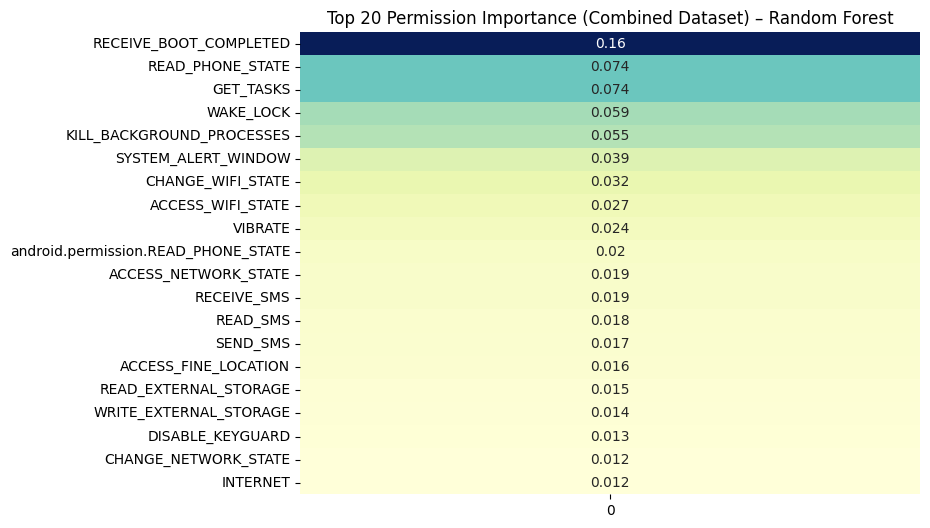

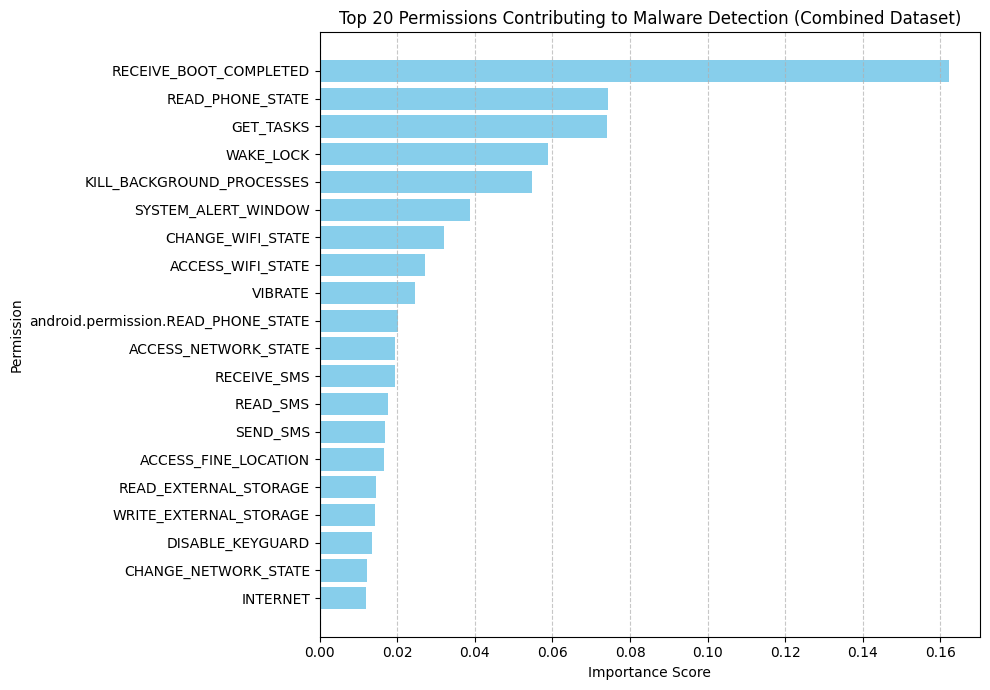

In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Get feature importances from the retrained Random Forest model
feature_importances_combined = rf_combined.feature_importances_

# Get feature names from the original (unscaled) X_combined DataFrame
features_combined = X_combined.columns

# Create a DataFrame for feature importances
importance_df_combined = pd.DataFrame({
    'Permission': features_combined,
    'Importance': feature_importances_combined
}).sort_values(by='Importance', ascending=False)

# Select the top 20 features
top_features_combined = importance_df_combined.head(20)

print("Top 20 Permission Importance (Combined Dataset) – Random Forest")
display(top_features_combined)

# Visualize top 20 feature importances using a heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    np.array(top_features_combined["Importance"]).reshape(-1,1),
    annot=True,
    yticklabels=top_features_combined["Permission"],
    cmap="YlGnBu",
    cbar=False
)
plt.title("Top 20 Permission Importance (Combined Dataset) – Random Forest")
plt.show()

# Also visualize with a bar plot for better readability
plt.figure(figsize=(10, 7))
plt.barh(top_features_combined["Permission"], top_features_combined["Importance"], color='skyblue')
plt.gca().invert_yaxis() # Display highest importance at the top
plt.xlabel("Importance Score")
plt.ylabel("Permission")
plt.title("Top 20 Permissions Contributing to Malware Detection (Combined Dataset)")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Project Explanation Outline: Enhanced Android Malware Detection

This project aims to enhance Android malware detection capabilities by integrating and leveraging a more comprehensive dataset and evaluating various machine learning models. The key steps and findings are outlined below:

### 1. Data Loading and Initial Exploration
- **Loaded initial dataset:** `Android Malware Detection.csv` was loaded and explored to understand its structure and initial features.
- **Loaded second dataset:** `train.csv` was loaded and its structure was inspected. A crucial step involved correcting the delimiter (`sep=';'`) and renaming the target column from 'type' to 'Label' for consistency.

### 2. Dataset Integration and Preprocessing
- **Merging Datasets:** The two datasets (`df` and `train_df`) were combined into a single `combined_df`. This involved:
    - Dropping an artifact 'Unnamed: 0' column from the initial `df`.
    - Identifying a union of all unique features (permissions) across both datasets.
    - Aligning columns and filling missing feature values with 0 to ensure uniform dimensions.
    - Concatenating the aligned dataframes.
- **Handling Missing Values:** Rows with missing values in the 'Label' column were dropped from `combined_df` to ensure data integrity for model training.
- **Feature-Target Split:** The combined dataset was split into features (X_combined) and the target variable (y_combined, which is 'Label').
- **Train-Test Split:** The data was divided into training and testing sets (80% train, 20% test) using `train_test_split` with `random_state=42` for reproducibility.
- **Feature Scaling:** Features were scaled using `StandardScaler` to normalize their ranges, which is essential for models like SVM and can improve the performance of others.

### 3. Machine Learning Model Training and Evaluation
All models were re-trained and evaluated on the preprocessed `combined_df`.

- **Random Forest Classifier (`rf_combined`):**
    - Trained with `n_estimators=100` and `random_state=42`.
    - Achieved strong performance (Accuracy ~0.98).
- **Support Vector Machine (SVM) (`svm_combined`):**
    - Trained with a Radial Basis Function (RBF) kernel and `probability=True`.
    - Showed good performance (Accuracy ~0.97).
- **Naive Bayes (`nb_combined`):**
    - Trained using `GaussianNB`.
    - Demonstrated lower performance compared to tree-based and SVM models (Accuracy ~0.31), indicating its assumptions might not fit the data well.
- **PCA-Random Forest (`rf_pca_combined`):**
    - Principal Component Analysis (PCA) was applied, retaining components explaining 90% of variance (`n_components=0.90`).
    - A Random Forest classifier was trained on the PCA-transformed data.
    - Maintained high accuracy (Accuracy ~0.98), suggesting effective dimensionality reduction without significant loss of information.
- **Proposed Stacking Ensemble (`stack_combined`):**
    - Implemented a Stacking Classifier with Random Forest, SVM, and Naive Bayes as base estimators.
    - A Logistic Regression model was used as the final estimator (meta-learner).
    - Achieved a very competitive accuracy (Accuracy ~0.98), demonstrating the potential benefits of ensemble methods.

### 4. Performance Visualizations
- **Classification Reports:** Detailed reports for each model were generated, providing precision, recall, f1-score, and support for both 'Benign' (0) and 'Malware' (1) classes.
- **Model Performance Metrics Bar Plot:** A bar chart visually compared the Accuracy, Precision, Recall, and F1-Score of all models, offering an easy comparison of their overall effectiveness.
- **Confusion Matrices:** Visualized for each model, showing the counts of True Positives, True Negatives, False Positives, and False Negatives, aiding in understanding classification errors.
- **ROC Curves:** Plotted for all models, illustrating the trade-off between True Positive Rate and False Positive Rate. AUC scores were used for comparison.
- **Precision-Recall Curves:** Generated to evaluate model performance, especially useful for imbalanced datasets, by plotting precision against recall.
- **Radar Chart:** Provided a multi-dimensional comparison of Accuracy, Precision, Recall, and F1-Score for all models on a single plot.

### 5. Feature Importance Analysis
- **Top 20 Feature Importances:** The feature importances from the `rf_combined` model were extracted and visualized (both as a DataFrame and a bar plot/heatmap).
    - This identified the most critical permissions that significantly influence the model's decision-making process in classifying Android applications as benign or malicious.

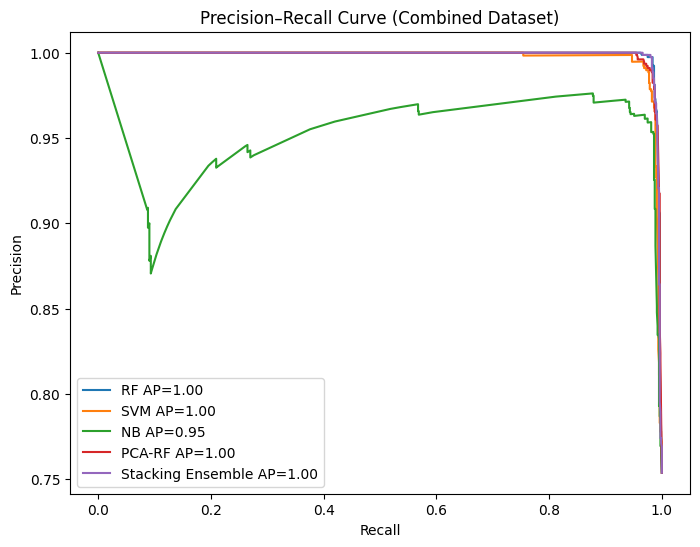

In [102]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Prepare list of models and their predictions for PR curve plotting
models_for_pr_curve_combined = {
    "RF": rf_combined,
    "SVM": svm_combined,
    "NB": nb_combined,
    "PCA-RF": rf_pca_combined,
    "Stacking Ensemble": stack_combined
}

for name, model in models_for_pr_curve_combined.items():
    if name == "PCA-RF":
        probs = model.predict_proba(X_test_pca_combined)[:,1]
    else:
        probs = model.predict_proba(X_test_scaled)[:,1]

    precision, recall, _ = precision_recall_curve(y_test_combined, probs)
    ap = average_precision_score(y_test_combined, probs)
    plt.plot(recall, precision, label=f"{name} AP={ap:.2f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Combined Dataset)")
plt.legend()
plt.show()

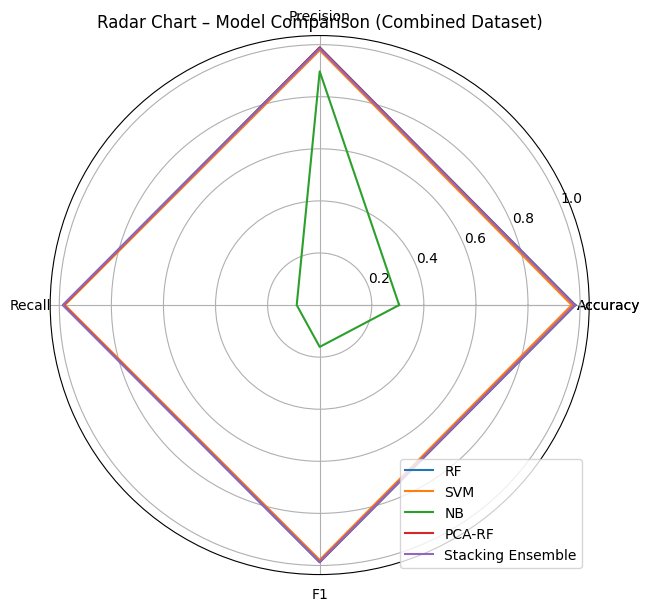

In [104]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

metrics = ["Accuracy","Precision","Recall","F1"]

def get_scores(y_true, y_pred):
    return [
        accuracy_score(y_true,y_pred),
        precision_score(y_true,y_pred),
        recall_score(y_true,y_pred),
        f1_score(y_true,y_pred)
    ]

rf_scores_combined = get_scores(y_test_combined, rf_pred_combined)
svm_scores_combined = get_scores(y_test_combined, svm_pred_combined)
nb_scores_combined = get_scores(y_test_combined, nb_pred_combined)
rf_pca_scores_combined = get_scores(y_test_combined, rf_pca_pred_combined)
stack_scores_combined = get_scores(y_test_combined, stack_pred_combined)

angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False)
angles = np.concatenate([angles, [angles[0]]]) # Close the loop for plotting

plt.figure(figsize=(7,7))
for scores, label in zip(
    [rf_scores_combined, svm_scores_combined, nb_scores_combined, rf_pca_scores_combined, stack_scores_combined],
    ["RF","SVM","NB","PCA-RF","Stacking Ensemble"]
):
    scores = scores + [scores[0]] # Close the loop for the data
    plt.polar(angles, scores, label=label)

# Extend metrics to match the length of angles for thetagrids
metrics_for_thetagrids = metrics + [metrics[0]]
plt.thetagrids(angles*180/np.pi, metrics_for_thetagrids)
plt.title("Radar Chart – Model Comparison (Combined Dataset)")
plt.legend(loc="lower right")
plt.show()

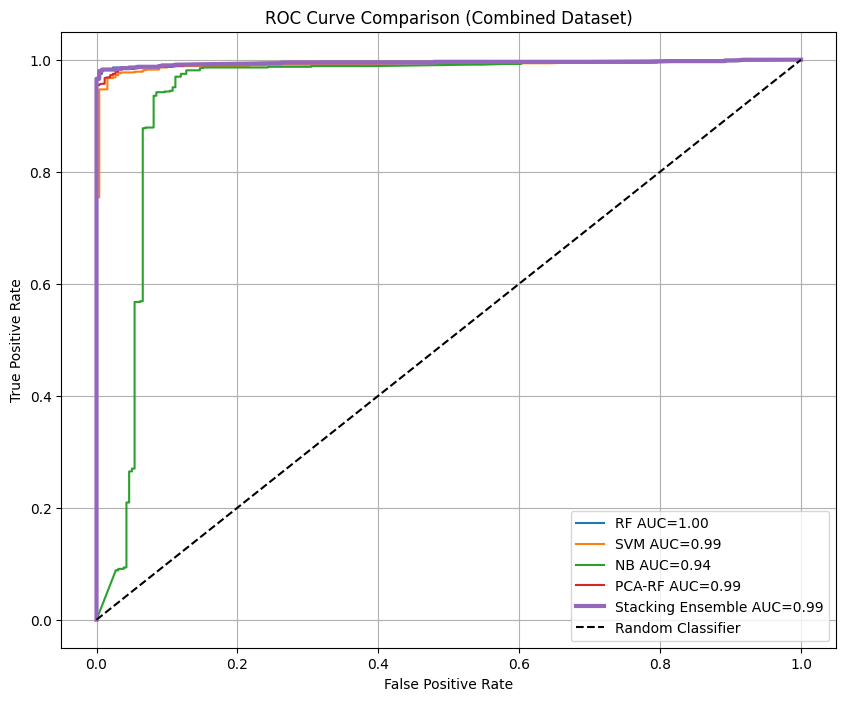

In [98]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Get ROC curve for Random Forest
rf_fpr_combined, rf_tpr_combined, _ = roc_curve(y_test_combined, rf_combined.predict_proba(X_test_scaled)[:, 1])
plt.plot(rf_fpr_combined, rf_tpr_combined, label=f"RF AUC={auc(rf_fpr_combined, rf_tpr_combined):.2f}")

# Get ROC curve for SVM
svm_fpr_combined, svm_tpr_combined, _ = roc_curve(y_test_combined, svm_combined.predict_proba(X_test_scaled)[:, 1])
plt.plot(svm_fpr_combined, svm_tpr_combined, label=f"SVM AUC={auc(svm_fpr_combined, svm_tpr_combined):.2f}")

# Get ROC curve for Naive Bayes
nb_fpr_combined, nb_tpr_combined, _ = roc_curve(y_test_combined, nb_combined.predict_proba(X_test_scaled)[:, 1])
plt.plot(nb_fpr_combined, nb_tpr_combined, label=f"NB AUC={auc(nb_fpr_combined, nb_tpr_combined):.2f}")

# Get ROC curve for PCA-RF (note: rf_pca_combined predicts on X_test_pca_combined)
rf_pca_fpr_combined, rf_pca_tpr_combined, _ = roc_curve(y_test_combined, rf_pca_combined.predict_proba(X_test_pca_combined)[:, 1])
plt.plot(rf_pca_fpr_combined, rf_pca_tpr_combined, label=f"PCA-RF AUC={auc(rf_pca_fpr_combined, rf_pca_tpr_combined):.2f}")

# Get ROC curve for Stacking Ensemble
stack_fpr_combined, stack_tpr_combined, _ = roc_curve(y_test_combined, stack_combined.predict_proba(X_test_scaled)[:, 1])
plt.plot(stack_fpr_combined, stack_tpr_combined, label=f"Stacking Ensemble AUC={auc(stack_fpr_combined, stack_tpr_combined):.2f}", linewidth=3)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (Combined Dataset)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

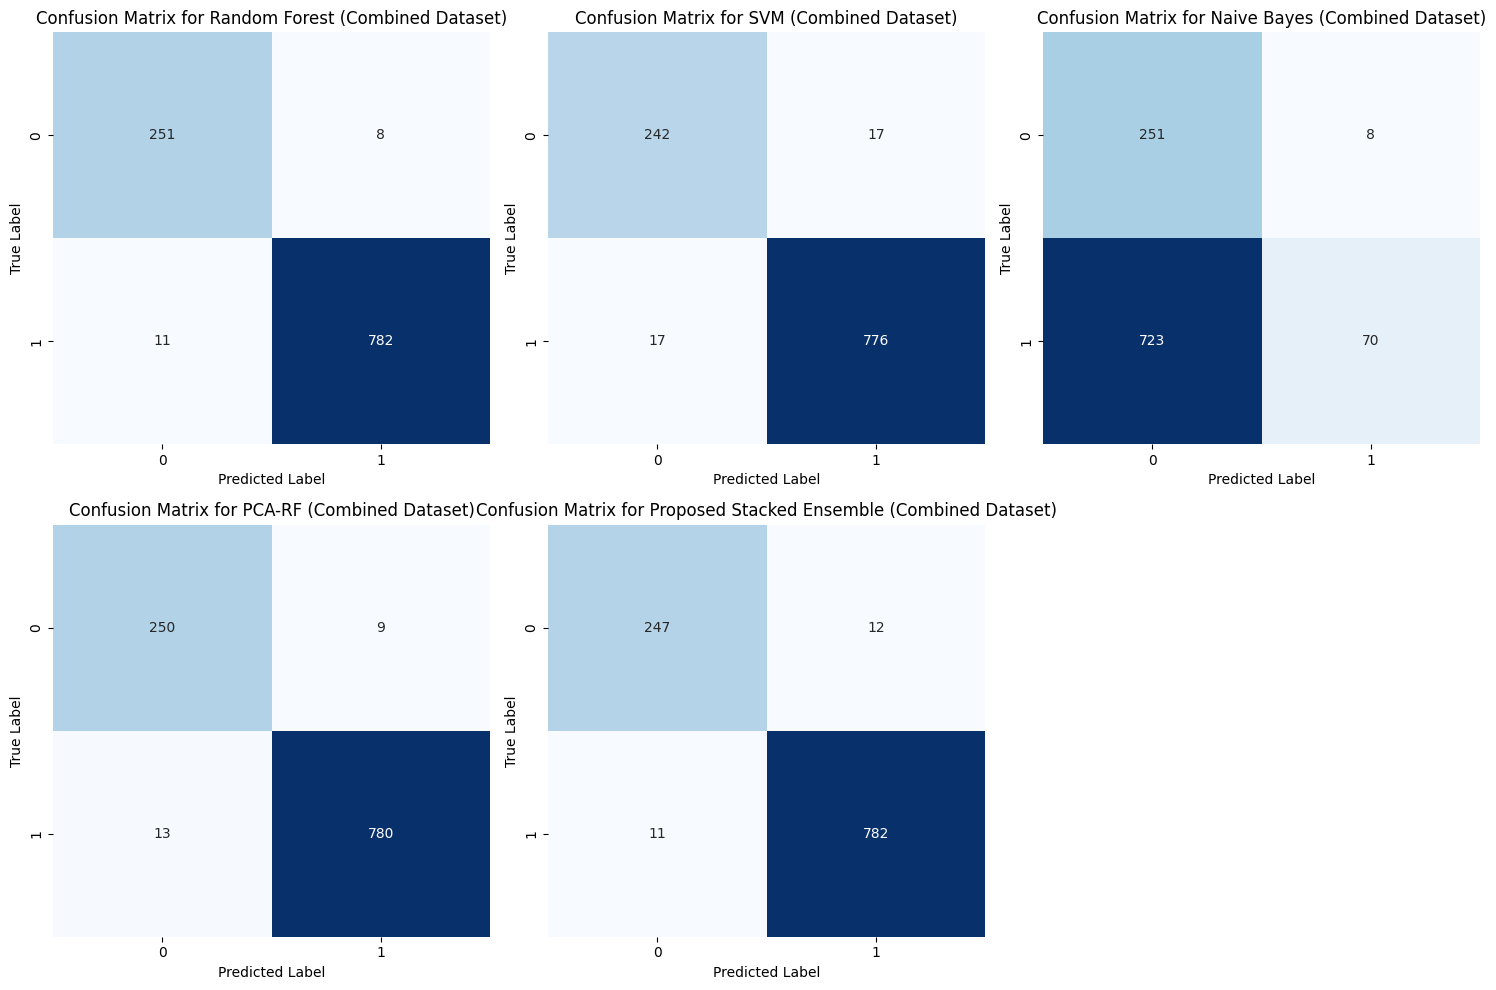

In [94]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming y_test_combined and prediction arrays for each model are available
models_combined = {
    "Random Forest": rf_pred_combined,
    "SVM": svm_pred_combined,
    "Naive Bayes": nb_pred_combined,
    "PCA-RF": rf_pca_pred_combined,
    "Proposed Stacked Ensemble": stack_pred_combined
}

plt.figure(figsize=(15, 10)) # Adjust figure size for better readability of multiple plots

for i, (name, pred) in enumerate(models_combined.items(), 1):
    plt.subplot(2, 3, i) # Creating a 2x3 grid for 5 models
    cm_combined = confusion_matrix(y_test_combined, pred)
    sns.heatmap(cm_combined, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix for {name} (Combined Dataset)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

In [111]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

stack_combined = StackingClassifier(
    estimators=[
        ('rf', rf_combined),
        ('svm', svm_combined),
        ('nb', nb_combined)
    ],
    final_estimator=LogisticRegression()
)

stack_combined.fit(X_train_scaled, y_train_combined)
stack_pred_combined = stack_combined.predict(X_test_scaled)

print("Stacking Ensemble Performance (Combined Dataset)")
print(classification_report(y_test_combined, stack_pred_combined))

Stacking Ensemble Performance (Combined Dataset)
              precision    recall  f1-score   support

         0.0       0.96      0.95      0.96       259
         1.0       0.98      0.99      0.99       793

    accuracy                           0.98      1052
   macro avg       0.97      0.97      0.97      1052
weighted avg       0.98      0.98      0.98      1052



In [112]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report

nb_combined = GaussianNB()
nb_combined.fit(X_train_scaled, y_train_combined)

nb_pred_combined = nb_combined.predict(X_test_scaled)
print("Naive Bayes Results (Combined Dataset)")
print(classification_report(y_test_combined, nb_pred_combined))

Naive Bayes Results (Combined Dataset)
              precision    recall  f1-score   support

         0.0       0.26      0.97      0.41       259
         1.0       0.90      0.09      0.16       793

    accuracy                           0.31      1052
   macro avg       0.58      0.53      0.28      1052
weighted avg       0.74      0.31      0.22      1052



In [90]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.naive_bayes import GaussianNB # Import GaussianNB

# Ensure base models are trained on the combined dataset
# rf_combined, svm_combined are assumed to be trained from previous steps

# Train Naive Bayes model within this cell for dependency
nb_combined = GaussianNB()
nb_combined.fit(X_train_scaled, y_train_combined)
nb_pred_combined = nb_combined.predict(X_test_scaled) # Define nb_pred_combined here too

stack_combined = StackingClassifier(
    estimators=[
        ('rf', rf_combined),
        ('svm', svm_combined),
        ('nb', nb_combined)
    ],
    final_estimator=LogisticRegression()
)

stack_combined.fit(X_train_scaled, y_train_combined)
stack_pred_combined = stack_combined.predict(X_test_scaled)

print("Stacking Ensemble Performance (Combined Dataset)")
print(classification_report(y_test_combined, stack_pred_combined))

Stacking Ensemble Performance (Combined Dataset)
              precision    recall  f1-score   support

         0.0       0.96      0.95      0.96       259
         1.0       0.98      0.99      0.99       793

    accuracy                           0.98      1052
   macro avg       0.97      0.97      0.97      1052
weighted avg       0.98      0.98      0.98      1052



,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.981939,0.982030,0.981939,0.981974
1,SVM,0.967681,0.967681,0.967681,0.967681
2,Naive Bayes,0.305133,0.739934,0.305133,0.221398
3,PCA-RF,0.979087,0.979232,0.979087,0.979141
4,Proposed Stacked Ensemble,0.978137,0.978111,0.978137,0.978123


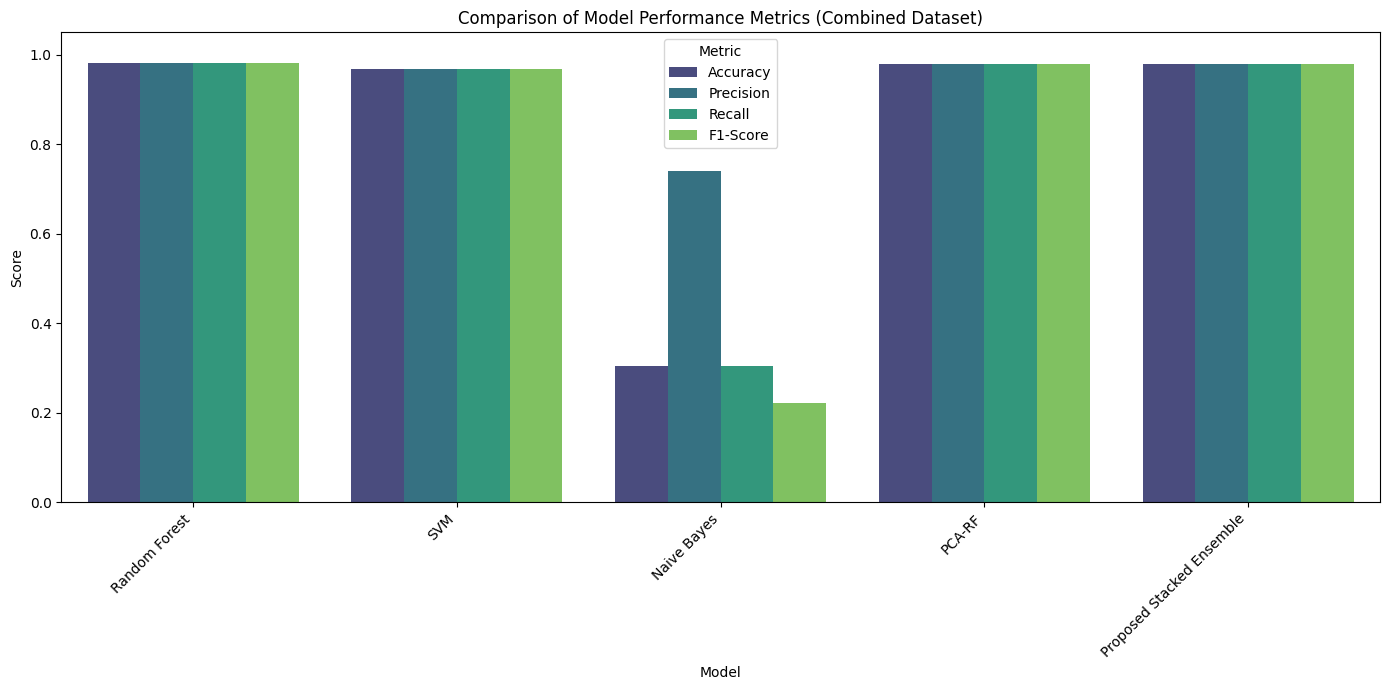

In [91]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Helper function to extract relevant metrics for a model
def get_model_metrics(y_true, y_pred, model_name):
    report = classification_report(y_true, y_pred, output_dict=True)
    accuracy = report['accuracy']
    precision = report['weighted avg']['precision']
    recall = report['weighted avg']['recall']
    f1 = report['weighted avg']['f1-score']
    return {"Model": model_name, "Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1-Score": f1}

# Collect metrics for all models on the combined dataset
results_data_combined = []
results_data_combined.append(get_model_metrics(y_test_combined, rf_pred_combined, "Random Forest"))
results_data_combined.append(get_model_metrics(y_test_combined, svm_pred_combined, "SVM"))
results_data_combined.append(get_model_metrics(y_test_combined, nb_pred_combined, "Naive Bayes"))
results_data_combined.append(get_model_metrics(y_test_combined, rf_pca_pred_combined, "PCA-RF"))
results_data_combined.append(get_model_metrics(y_test_combined, stack_pred_combined, "Proposed Stacked Ensemble"))

final_results_combined = pd.DataFrame(results_data_combined)
display(final_results_combined)

# Plotting the metrics
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

plt.figure(figsize=(14, 7))

# Melt the DataFrame for easy plotting with seaborn
melted_results = final_results_combined.melt(id_vars='Model', value_vars=metrics_to_plot, var_name='Metric', value_name='Score')

sns.barplot(x='Model', y='Score', hue='Metric', data=melted_results, palette='viridis')
plt.ylim(0, 1.05)
plt.title('Comparison of Model Performance Metrics (Combined Dataset)')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

In [83]:
from sklearn.svm import SVC

svm_combined = SVC(kernel="rbf", probability=True, random_state=42)
svm_combined.fit(X_train_scaled, y_train_combined)

svm_pred_combined = svm_combined.predict(X_test_scaled)
print("SVM Results (Combined Dataset)")
print(classification_report(y_test_combined, svm_pred_combined))

SVM Results (Combined Dataset)
              precision    recall  f1-score   support

         0.0       0.93      0.93      0.93       259
         1.0       0.98      0.98      0.98       793

    accuracy                           0.97      1052
   macro avg       0.96      0.96      0.96      1052
weighted avg       0.97      0.97      0.97      1052



## Retrain and Evaluate Models on Combined Dataset

### Subtask:
Retrain all previously implemented machine learning models (Random Forest, SVM, Naive Bayes, PCA-RF, and Stacking Ensemble) on the enriched `combined_df` dataset. After retraining each model, evaluate its performance and update all relevant visualizations and metrics.

In [82]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf_combined = RandomForestClassifier(n_estimators=100, random_state=42)
rf_combined.fit(X_train_scaled, y_train_combined)

rf_pred_combined = rf_combined.predict(X_test_scaled)
print("Random Forest Results (Combined Dataset)")
print(classification_report(y_test_combined, rf_pred_combined))

Random Forest Results (Combined Dataset)
              precision    recall  f1-score   support

         0.0       0.96      0.97      0.96       259
         1.0       0.99      0.99      0.99       793

    accuracy                           0.98      1052
   macro avg       0.97      0.98      0.98      1052
weighted avg       0.98      0.98      0.98      1052



## Preprocessing Combined Dataset

### Subtask:
Prepare the `combined_df` for model training. This includes handling any missing values in the 'Label' column, separating features (X) from the target variable (y), splitting the data into training and testing sets, and scaling the features using `StandardScaler`.

In [81]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Drop rows where 'Label' column has NaN values from the combined_df
combined_df_cleaned = combined_df.dropna(subset=['Label'])

X_combined = combined_df_cleaned.drop("Label", axis=1)   # Target variable is 'Label'
y_combined = combined_df_cleaned["Label"]

# Perform train-test split
X_train_combined, X_test_combined, y_train_combined, y_test_combined = train_test_split(
    X_combined, y_combined, test_size=0.2, random_state=42
)

# Scale the features
scaler_combined = StandardScaler()
X_train_scaled = scaler_combined.fit_transform(X_train_combined)
X_test_scaled = scaler_combined.transform(X_test_combined)

print(f"Shape of X_train_scaled: {X_train_scaled.shape}")
print(f"Shape of X_test_scaled: {X_test_scaled.shape}")
print(f"Shape of y_train_combined: {y_train_combined.shape}")
print(f"Shape of y_test_combined: {y_test_combined.shape}")

Shape of X_train_scaled: (4208, 478)
Shape of X_test_scaled: (1052, 478)
Shape of y_train_combined: (4208,)
Shape of y_test_combined: (1052,)


## Merging Datasets

### Subtask:
Combine the `df` (from 'Android Malware Detection.csv') and `train_df` (from 'train.csv') datasets into a single DataFrame. This involves handling differing columns by creating a union of all unique permissions and filling missing values with 0, then concatenating the rows. The resulting DataFrame will be named `combined_df`.

In [80]:
import pandas as pd

# Step 1: Drop 'Unnamed: 0' from df if it exists, as it appears to be an artifact index
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# Step 2: Get all unique column names (features) from both dataframes, excluding the 'Label' column
df_features = set(df.columns) - {'Label'}
train_df_features = set(train_df.columns) - {'Label'}

all_features = sorted(list(df_features.union(train_df_features)))

# Step 3: Align columns for both dataframes, filling missing feature values with 0
# Use .copy() to avoid SettingWithCopyWarning later
df_aligned = df.reindex(columns=all_features, fill_value=0).copy()
train_df_aligned = train_df.reindex(columns=all_features, fill_value=0).copy()

# Add the 'Label' column back to the aligned dataframes
df_aligned['Label'] = df['Label']
train_df_aligned['Label'] = train_df['Label']

# Step 4: Concatenate the two aligned dataframes
combined_df = pd.concat([df_aligned, train_df_aligned], ignore_index=True)

# Step 5: Display information about the combined dataframe
print(f"Shape of original df (after dropping 'Unnamed: 0'): {df.shape}")
print(f"Shape of train_df: {train_df.shape}")
print(f"Shape of combined_df: {combined_df.shape}")
display(combined_df.head())

Shape of original df (after dropping 'Unnamed: 0'): (4863, 149)
Shape of train_df: (398, 331)
Shape of combined_df: (5261, 479)


,ACCESS_ALL_DOWNLOADS,ACCESS_CACHE_FILESYSTEM,ACCESS_CHECKIN_PROPERTIES,ACCESS_COARSE_LOCATION,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MOCK_LOCATION,ACCESS_NETWORK_STATE,ACCESS_SURFACE_FLINGER,ACCESS_WIFI_STATE,...,com.android.voicemail.permission.WRITE_VOICEMAIL,com.foo.mypermission,com.foo.mypermission2,org.chromium.chrome.shell.permission.C2D_MESSAGE,org.chromium.chrome.shell.permission.DEBUG,org.chromium.chrome.shell.permission.SANDBOX,org.chromium.chromecast.shell.permission.SANDBOX,org.chromium.content_shell.permission.SANDBOX,test_permission,Label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0,0,0,0,0,0,0,0,0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0,0,0,0,0,0,0,0,0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1.0


**Reasoning**:
The previous `pd.read_csv` call did not correctly parse the 'train.csv' file, resulting in a single column with all data. This indicates that the file is not comma-separated. By inspecting the output, it appears the columns are separated by semicolons. I will reload the `train.csv` file, specifying the semicolon (`;`) as the separator, and then display its head to verify the correct loading.



In [74]:
train_df = pd.read_csv('/content/train.csv', sep=';')
train_df.head()

,android,android.app.cts.permission.TEST_GRANTED,android.intent.category.MASTER_CLEAR.permission.C2D_MESSAGE,android.os.cts.permission.TEST_GRANTED,android.permission.ACCESS_ALL_DOWNLOADS,android.permission.ACCESS_ALL_EXTERNAL_STORAGE,android.permission.ACCESS_BLUETOOTH_SHARE,android.permission.ACCESS_CACHE_FILESYSTEM,android.permission.ACCESS_CHECKIN_PROPERTIES,android.permission.ACCESS_COARSE_LOCATION,...,com.android.voicemail.permission.WRITE_VOICEMAIL,com.foo.mypermission,com.foo.mypermission2,org.chromium.chrome.shell.permission.C2D_MESSAGE,org.chromium.chrome.shell.permission.DEBUG,org.chromium.chrome.shell.permission.SANDBOX,org.chromium.chromecast.shell.permission.SANDBOX,org.chromium.content_shell.permission.SANDBOX,test_permission,type
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


**Reasoning**:
The 'train_df' has been loaded, but its label column is named 'type'. To prepare for merging with the original 'df', which has a 'Label' column, I need to rename the 'type' column in 'train_df' to 'Label'. This ensures consistency in the target variable name across both datasets.



In [75]:
train_df = train_df.rename(columns={'type': 'Label'})

**Reasoning**:
The 'train_df' has been loaded, but its label column is named 'type'. To prepare for merging with the original 'df', which has a 'Label' column, I need to rename the 'type' column in 'train_df' to 'Label'. This ensures consistency in the target variable name across both datasets.



**Reasoning**:
After renaming the 'type' column to 'Label' in `train_df`, it is important to display the head of the DataFrame again to visually confirm that the column name change has been applied correctly and to verify the updated structure.



## Explore Second Dataset

### Subtask:
Perform initial exploratory data analysis on the `train.csv` dataset, including displaying its information (`.info()`) to check data types and non-null counts, and descriptive statistics (`.describe()`) to understand the distribution of its columns. This will help confirm its alignment with the existing 'Android Malware Detection.csv' dataset.


**Reasoning**:
To perform initial exploratory data analysis on the `train_df` dataset, I will display its information using `.info()` to check data types and non-null counts, and then its descriptive statistics using `.describe()` to understand the distribution of its columns.



In [78]:
print(train_df.info())
print(train_df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Columns: 331 entries, android to Label
dtypes: int64(331)
memory usage: 1.0 MB
None
       android  android.app.cts.permission.TEST_GRANTED  \
count    398.0                                    398.0   
mean       0.0                                      0.0   
std        0.0                                      0.0   
min        0.0                                      0.0   
25%        0.0                                      0.0   
50%        0.0                                      0.0   
75%        0.0                                      0.0   
max        0.0                                      0.0   

       android.intent.category.MASTER_CLEAR.permission.C2D_MESSAGE  \
count                                              398.0             
mean                                                 0.0             
std                                                  0.0             
min                             